## 2. Dataset Selection

### 2.1 Dataset Requirements

The selected dataset satisfies the main technical requirements of the assignment:

* It contains tabular data in CSV format.
* It contains 106,876 rows and 17 columns.
* It contains more than 1,000 observations and more than 10 variables.
* It includes numerical variables, such as match scores and points.
* It includes categorical variables, such as teams, countries, competitions, and match locations.
* It includes temporal variables, such as match date, match time, and season.

Therefore, the dataset is suitable for exploratory data analysis and for the different statistical and visual analyses required in this assignment.


In [61]:
from pathlib import Path
import pandas as pd

# Define the path to the dataset file
dataset_path = Path("data") / "Full_Dataset.csv"

# Load the CSV file into a Pandas DataFrame
football_matches_df = pd.read_csv(dataset_path)

# Display the dataset dimensions
print(f"Number of rows: {football_matches_df.shape[0]:,}")
print(f"Number of columns: {football_matches_df.shape[1]}")

Number of rows: 106,876
Number of columns: 17


### 2.2 Dataset Source Description

#### Data Source

The dataset used in this analysis is titled **European Soccer Data** and was downloaded from Kaggle. It was published on Kaggle by Will Fitzhugh.

According to the dataset description, it contains historical football match data from major European domestic leagues, domestic cup competitions, the UEFA Champions League, and the UEFA Europa League. The dataset covers competitions from England, Spain, Germany, Italy, and France.

The downloaded data is stored in a file named `Full_Dataset.csv`.

#### Purpose of the Data

The apparent purpose of the dataset is to combine historical European football match results into a single structured and cleaned table. This structure supports exploratory analysis, statistical comparisons, visualization, and the investigation of patterns across teams, countries, competitions, and seasons.

The dataset can be used to examine questions such as:

* Whether teams perform better at home than away.
* Whether scoring patterns differ between countries or competitions.
* Whether the average number of goals changes over time.
* Which teams accumulated the highest number of points.
* Whether knockout competitions differ from league competitions.
* How frequently matches require extra time or penalty shootouts.

The dataset description does not state that the data was collected for a specific scientific study. Therefore, it is more reasonable to treat it as a compiled historical dataset intended for analysis and visualization rather than as data collected under a controlled research protocol.

#### Data Collector and Publisher

The Kaggle dataset was published by Will Fitzhugh. However, the available dataset description does not fully identify the original organizations, websites, or data providers from which every match record was collected.

This missing provenance information is an important limitation. Although the data is described as cleaned historical football data, the absence of a complete description of the original collection process makes it difficult to independently evaluate:

* The accuracy of every record.
* Whether all competitions and seasons were collected consistently.
* Whether corrections were made to historical results.
* How postponed, abandoned, or replayed matches were handled.
* Whether the meaning of variables remained consistent over time.

Therefore, Kaggle should be considered the distribution platform and Will Fitzhugh the dataset publisher, but they should not automatically be assumed to be the original collectors of all match information.

#### Unit of Observation

A single row does not represent a unique football match in the conventional sense. Instead, each row represents a match occurrence from the perspective of one participating team.

For example, a match between Team A and Team B will normally appear twice:

1. One row in which Team A is stored in the `Team` column and Team B is stored in the `Opponent` column.
2. A second row in which Team B is stored in the `Team` column and Team A is stored in the `Opponent` column.

As a result, the 106,876 rows correspond to approximately half as many physical matches. This structure is useful for team-level comparisons, but it creates an important analytical assumption: match-level calculations may count each match twice unless the data is filtered or aggregated appropriately.

#### Domain Knowledge and Connection to the Table

Football matches are commonly analyzed using wins, draws, losses, goals, points, home advantage, competition type, and season. These concepts are represented directly in the dataset.

The `Team_Score` and `Opponent_Score` columns describe the number of goals scored by the selected team and its opponent. The `Team_Points` and `Opponent_Points` columns represent the points assigned to each side, typically using the standard league system of three points for a win, one point for a draw, and zero points for a loss.

The `Location` variable indicates whether the selected team played at home or away. This variable is especially useful for investigating home advantage.

The `Home_Score_AET`, `Away_Score_AET`, `Home_Penalties`, and `Away_Penalties` variables are mainly relevant to knockout matches. Missing values in these columns may not indicate poor data quality. In many cases, they correctly indicate that the match did not require extra time or a penalty shootout.

The dataset combines domestic leagues, domestic cups, and European competitions. These competition types do not always follow identical rules. League matches usually end after regular time and award points, while knockout matches may continue to extra time and penalties. Consequently, the variables must be interpreted according to the relevant competition context.


In [62]:
# Display the first five rows for an initial inspection of the dataset
football_matches_df.head()

,Round,Date,Time,Team,Team_Score,Opponent_Score,Opponent,Home_Score_AET,Away_Score_AET,Home_Penalties,Away_Penalties,Team_Points,Opponent_Points,season,Location,Country,Competition
0,ROUND 1,31/08/2002,22:30,RACING SANTANDER,0.0,1.0,VALLADOLID,NaN,NaN,NaN,NaN,0.0,3.0,2002,Home,spain,primera-division
1,ROUND 1,01/09/2002,21:00,RAYO VALLECANO,2.0,2.0,ALAVES,NaN,NaN,NaN,NaN,1.0,1.0,2002,Home,spain,primera-division
2,ROUND 1,01/09/2002,21:00,REAL SOCIEDAD,4.0,2.0,ATHLETIC BILBAO,NaN,NaN,NaN,NaN,3.0,0.0,2002,Home,spain,primera-division
3,ROUND 1,01/09/2002,22:00,MALLORCA,0.0,2.0,VALENCIA,NaN,NaN,NaN,NaN,0.0,3.0,2002,Home,spain,primera-division
4,ROUND 1,01/09/2002,22:30,VILLARREAL,2.0,2.0,OSASUNA,NaN,NaN,NaN,NaN,1.0,1.0,2002,Home,spain,primera-division


#### Initial Observation

The first rows show that the dataset combines match identification variables, temporal variables, team information, scores, competition information, and location information.

At this stage, the `Date` and `Time` columns appear as text values rather than parsed temporal variables. Their exact data types will be examined and corrected, if necessary, during the structural analysis of the dataset.

The sample also supports the interpretation that each row describes the match from the perspective of the team stored in the `Team` column.


In [63]:
# Find both team-perspective records for the first match
example_match = football_matches_df[
    (football_matches_df["Date"] == football_matches_df.loc[0, "Date"])
    & (
        football_matches_df["Team"].isin(
            [
                football_matches_df.loc[0, "Team"],
                football_matches_df.loc[0, "Opponent"],
            ]
        )
    )
    & (
        football_matches_df["Opponent"].isin(
            [
                football_matches_df.loc[0, "Team"],
                football_matches_df.loc[0, "Opponent"],
            ]
        )
    )
]

# Display the main match details from both perspectives
example_match[
    [
        "Date",
        "Team",
        "Opponent",
        "Team_Score",
        "Opponent_Score",
        "Location",
    ]
]

,Date,Team,Opponent,Team_Score,Opponent_Score,Location
0,31/08/2002,RACING SANTANDER,VALLADOLID,0.0,1.0,Home
7980,31/08/2002,VALLADOLID,RACING SANTANDER,1.0,0.0,Away


#### Section Conclusion

The selected dataset is suitable for the assignment because it contains a large number of observations, several variable types, multiple competitions, and a substantial temporal range.

However, two important limitations were identified during the source review. First, the complete original data collection process is not documented. Second, each physical match is normally represented by two team-perspective rows. Both issues must be considered when interpreting future statistics, identifying duplicates, and performing match-level analysis.


# 3. Meta Analysis of the Dataset

## 3.1 File Analysis

Before analyzing the data itself, it is important to examine the dataset as a file. This step provides basic information regarding the dataset format, storage characteristics, and metadata. Understanding these properties helps verify that the dataset was loaded correctly and provides useful context before performing any statistical analysis.


In [64]:
from datetime import datetime

# Get the file size and convert it from bytes to megabytes
file_size_bytes = dataset_path.stat().st_size
file_size_mb = file_size_bytes / (1024 ** 2)

# Get the local file creation and modification times
creation_time = datetime.fromtimestamp(dataset_path.stat().st_ctime)
modification_time = datetime.fromtimestamp(dataset_path.stat().st_mtime)

# Display the basic file metadata
print(f"File name: {dataset_path.name}")
print(f"File format: {dataset_path.suffix}")
print(f"File size: {file_size_mb:.2f} MB")
print(f"Creation time: {creation_time}")
print(f"Last modification time: {modification_time}")

File name: Full_Dataset.csv
File format: .csv
File size: 9.88 MB
Creation time: 2026-08-07 09:32:24.064524
Last modification time: 2026-07-24 11:25:48.544661


### Discussion

The dataset is stored as a CSV (Comma-Separated Values) file, which is one of the most common formats used in data science because it is lightweight, portable, and supported by most analytical tools.

The file metadata available through the operating system reflects the local copy stored on the current computer. Therefore, the creation and modification timestamps describe the local file rather than the original dataset publication date. Consequently, these timestamps should not be interpreted as the time when the dataset itself was created or collected.

The file size is relatively small, allowing the entire dataset to be loaded into memory efficiently using Pandas without requiring distributed computing or specialized storage solutions.


### Purpose of the Dataset

The dataset was created to provide historical football match information from major European competitions in a structured tabular format. It enables exploratory data analysis, statistical comparison between teams and competitions, visualization of football statistics, and the investigation of temporal trends across multiple seasons.


### Conclusions

The dataset is stored in a standard CSV format and can be processed efficiently using Python and Pandas.

The available file metadata refers only to the local copy of the dataset and should not be interpreted as information about the original data collection process.

Overall, the dataset structure and file format are appropriate for exploratory data analysis.


## 3.2 Dataset Structure

This section examines the dimensions, column names, data types, missing-value counts, and unique-value counts of the dataset. The objective is to identify structural properties that may affect the subsequent analysis.

In [65]:
import numpy as np
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix

# Get the dataset dimensions
row_count, column_count = football_matches_df.shape

# Display the number of rows, columns, and column names
print(f"Number of rows: {row_count:,}")
print(f"Number of columns: {column_count}")
print("\nColumn names:")
print(football_matches_df.columns.tolist())

Number of rows: 106,876
Number of columns: 17

Column names:
['Round', 'Date', 'Time', 'Team', 'Team_Score', 'Opponent_Score', 'Opponent', 'Home_Score_AET', 'Away_Score_AET', 'Home_Penalties', 'Away_Penalties', 'Team_Points', 'Opponent_Points', 'season', 'Location', 'Country', 'Competition']


In [66]:
# Display a concise summary of the dataset structure and data types
football_matches_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 106876 entries, 0 to 106875
Data columns (total 17 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   Round            106876 non-null  object 
 1   Date             106876 non-null  object 
 2   Time             106876 non-null  object 
 3   Team             106876 non-null  object 
 4   Team_Score       104412 non-null  float64
 5   Opponent_Score   104412 non-null  float64
 6   Opponent         106876 non-null  object 
 7   Home_Score_AET   3024 non-null    float64
 8   Away_Score_AET   3024 non-null    float64
 9   Home_Penalties   1806 non-null    float64
 10  Away_Penalties   1806 non-null    float64
 11  Team_Points      104412 non-null  float64
 12  Opponent_Points  104412 non-null  float64
 13  season           106876 non-null  int64  
 14  Location         106876 non-null  object 
 15  Country          106876 non-null  object 
 16  Competition      106876 non-null  obje

In [67]:
# Create a structural summary for each variable
structure_summary = pd.DataFrame({
    "Data Type": football_matches_df.dtypes.astype(str),
    "Missing Values": football_matches_df.isna().sum(),
    "Missing Percentage": (
        football_matches_df.isna().mean() * 100
    ).round(2),
    "Unique Values": football_matches_df.nunique(dropna=False),
})

# Display the summary table
structure_summary

,Data Type,Missing Values,Missing Percentage,Unique Values
Round,object,0,0.00,73
Date,object,0,0.00,4694
Time,object,0,0.00,126
Team,object,0,0.00,1966
Team_Score,float64,2464,2.31,16
Opponent_Score,float64,2464,2.31,16
Opponent,object,0,0.00,1966
Home_Score_AET,float64,103852,97.17,8
Away_Score_AET,float64,103852,97.17,8
Home_Penalties,float64,105070,98.31,15


### Structural Interpretation

The column names are generally descriptive and reflect the perspective-based organization of the dataset. Variables prefixed by `Team` describe the selected team, while variables prefixed by `Opponent` describe its opponent.

The `Date` and `Time` variables are initially stored as text. This is common in CSV files because the format does not preserve dedicated datetime types. They must be converted before chronological analysis.

The score, point, extra-time, and penalty variables are numerical. Team names, competition names, countries, rounds, and locations are categorical.

The dataset appears to originate from operational historical records rather than a controlled scientific experiment. As a result, possible biases include unequal competition coverage, changes in football rules across seasons, different tournament structures, and incomplete documentation of the original collection process.

# 4. Data Quality and Completeness

Data quality is examined through missing values, duplicate records, suspicious values, and variable cardinality. The goal is not to modify the dataset automatically, but to understand which observations require special interpretation.

## 4.1 Missing Values

The extent and pattern of missingness are examined for every variable. In football data, missing values may be structural rather than random, especially for extra-time and penalty-shootout variables.

In [68]:
# Create a summary of missing values for each variable
missing_summary = pd.DataFrame({
    "Missing Values": football_matches_df.isna().sum(),
    "Missing Percentage": (
        football_matches_df.isna().mean() * 100
    ).round(2),
}).sort_values(
    by="Missing Values",
    ascending=False,
)

# Display variables from highest to lowest number of missing values
missing_summary

,Missing Values,Missing Percentage
Away_Penalties,105070,98.31
Home_Penalties,105070,98.31
Home_Score_AET,103852,97.17
Away_Score_AET,103852,97.17
Opponent_Points,2464,2.31
Team_Score,2464,2.31
Team_Points,2464,2.31
Opponent_Score,2464,2.31
Round,0,0.00
Opponent,0,0.00


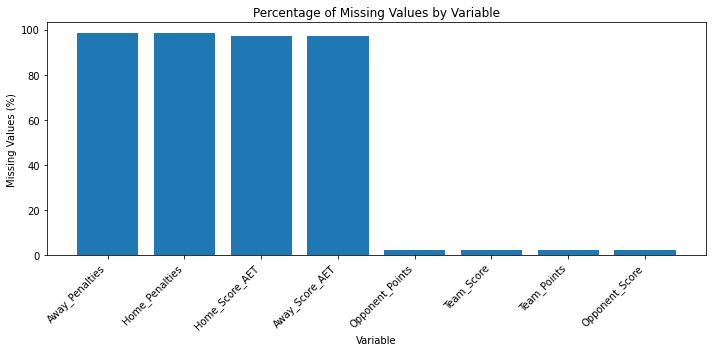

In [69]:
# Keep only variables that contain missing values
missing_columns = missing_summary[
    missing_summary["Missing Values"] > 0
]

# Visualize the percentage of missing values by variable
plt.figure(figsize=(10, 5))
plt.bar(
    missing_columns.index,
    missing_columns["Missing Percentage"],
)
plt.xticks(rotation=45, ha="right")
plt.xlabel("Variable")
plt.ylabel("Missing Values (%)")
plt.title("Percentage of Missing Values by Variable")
plt.tight_layout()
plt.show()

In [70]:
# Select extra-time and penalty variables for missing-pattern analysis
missing_pattern_columns = [
    "Home_Score_AET",
    "Away_Score_AET",
    "Home_Penalties",
    "Away_Penalties",
]

# Keep only columns that exist in the dataset
existing_missing_pattern_columns = [
    column_name
    for column_name in missing_pattern_columns
    if column_name in football_matches_df.columns
]

# Count the most common combinations of missing values
missing_pattern_counts = (
    football_matches_df[existing_missing_pattern_columns]
    .isna()
    .value_counts()
    .rename("Number of Rows")
    .reset_index()
)

missing_pattern_counts.head(10)

,Home_Score_AET,Away_Score_AET,Home_Penalties,Away_Penalties,Number of Rows
0,True,True,True,True,103456
1,False,False,True,True,1614
2,False,False,False,False,1410
3,True,True,False,False,396


### Missing-Value Discussion

Missingness is expected to be concentrated in extra-time and penalty-related variables. Most football matches end in regular time, and many competitions do not require a winner in every match. Consequently, the absence of an extra-time or penalty value often describes an event that did not occur rather than an unknown measurement.

The missing values should not be filled automatically in this analysis. A suitable completion strategy would depend on the intended use:

- Preserve `NaN` when it means that extra time or a penalty shootout did not occur.
- Add binary indicators such as `Extra_Time_Occurred` and `Penalty_Shootout_Occurred`.
- Replace missing values with zero only when the variable definition clearly states that non-occurrence is equivalent to zero.
- Use competition rules and match context before imputing any genuinely unknown value.

This distinction is important because replacing all missing values with a statistical average would create football events that never occurred and distort the data.

## 4.2 Duplicate Records

Duplicate analysis distinguishes between completely identical records, partial duplicates, and the intentional representation of one physical match from both team perspectives.

In [71]:
# Identify rows that are completely duplicated
complete_duplicate_mask = football_matches_df.duplicated(keep=False)

# Display the number and percentage of duplicated rows
print(
    f"Rows involved in complete duplication: "
    f"{complete_duplicate_mask.sum():,}"
)
print(
    f"Percentage of rows involved in complete duplication: "
    f"{complete_duplicate_mask.mean() * 100:.3f}%"
)

# Show examples of complete duplicates
football_matches_df.loc[complete_duplicate_mask].head(20)

Rows involved in complete duplication: 0
Percentage of rows involved in complete duplication: 0.000%


,Round,Date,Time,Team,Team_Score,Opponent_Score,Opponent,Home_Score_AET,Away_Score_AET,Home_Penalties,Away_Penalties,Team_Points,Opponent_Points,season,Location,Country,Competition


In [72]:
# Define the columns used to identify partial duplicates
partial_duplicate_key = [
    "Date",
    "Competition",
    "Team",
    "Opponent",
]

# Find rows that share the same partial duplicate key
partial_duplicate_mask = football_matches_df.duplicated(
    subset=partial_duplicate_key,
    keep=False,
)

print(
    f"Rows sharing the partial duplicate key: "
    f"{partial_duplicate_mask.sum():,}"
)

# Display examples of partial duplicates
football_matches_df.loc[
    partial_duplicate_mask,
    partial_duplicate_key
].sort_values(partial_duplicate_key).head(20)

Rows sharing the partial duplicate key: 0


,Date,Competition,Team,Opponent


In [73]:
# Create a match key that is identical for both team perspectives
perspective_match_key = (
    football_matches_df["Date"].astype(str)
    + " | "
    + football_matches_df[["Team", "Opponent"]]
      .astype(str)
      .apply(lambda row: " | ".join(sorted(row)), axis=1)
    + " | "
    + football_matches_df["Competition"].astype(str)
)

# Count how many perspective rows belong to each physical match
perspective_pair_counts = perspective_match_key.value_counts()

print("Distribution of team-perspective rows per physical-match key:")
print(perspective_pair_counts.value_counts().sort_index().head(10))

Distribution of team-perspective rows per physical-match key:
count
2    53438
Name: count, dtype: int64


### Duplicate Discussion

Completely identical rows are possible candidates for removal, but they should first be verified because repeated source records may contain contextual meaning.

The reversed team-perspective rows are not accidental duplicates. They allow team-level analyses, such as comparing home and away performance, but they also create a dependence between observations. Treating all rows as independent may underestimate uncertainty and double-count physical matches.

For team-level analyses, the perspective rows should be retained. For physical match-level analyses, one row per match should be selected or a unique match identifier should be constructed.

## 4.3 Suspicious Values

Suspicious values include impossible numerical values, placeholder codes, inconsistent score relationships, and rare extreme observations.

In [74]:
# Select all numerical variables
numeric_columns = football_matches_df.select_dtypes(
    include="number"
).columns.tolist()

# Summarize extreme, negative, and zero values
suspicious_numeric_summary = pd.DataFrame({
    "Minimum": football_matches_df[numeric_columns].min(),
    "Maximum": football_matches_df[numeric_columns].max(),
    "Negative Values": (
        football_matches_df[numeric_columns] < 0
    ).sum(),
    "Zero Values": (
        football_matches_df[numeric_columns] == 0
    ).sum(),
})

suspicious_numeric_summary

,Minimum,Maximum,Negative Values,Zero Values
Team_Score,0.0,15.0,0,29643
Opponent_Score,0.0,15.0,0,29643
Home_Score_AET,0.0,8.0,0,640
Away_Score_AET,0.0,6.0,0,640
Home_Penalties,0.0,13.0,0,26
Away_Penalties,0.0,14.0,0,30
Team_Points,0.0,3.0,0,40444
Opponent_Points,0.0,3.0,0,40444
season,2002.0,2022.0,0,0


In [75]:
# Define common placeholder values that may represent missing or invalid data
placeholder_values = [
    -1,
    -99,
    -999,
    999,
    9999,
    "Unknown",
    "N/A",
    "NA",
    "None",
    "",
]

placeholder_records = []

# Count the occurrences of each placeholder value in the dataset
for placeholder_value in placeholder_values:
    occurrence_count = (
        football_matches_df == placeholder_value
    ).sum().sum()

    if occurrence_count > 0:
        placeholder_records.append({
            "Placeholder Value": placeholder_value,
            "Occurrences": occurrence_count,
        })

# Display only placeholder values that were found
pd.DataFrame(placeholder_records)

""


In [76]:
# Check for logically impossible negative scores and points
logical_checks = {
    "Negative team scores": (
        football_matches_df["Team_Score"] < 0
    ).sum(),
    "Negative opponent scores": (
        football_matches_df["Opponent_Score"] < 0
    ).sum(),
    "Negative team points": (
        football_matches_df["Team_Points"] < 0
    ).sum(),
    "Negative opponent points": (
        football_matches_df["Opponent_Points"] < 0
    ).sum(),
}

# Display the number of suspicious rows for each check
pd.Series(logical_checks, name="Number of Suspicious Rows")

Negative team scores        0
Negative opponent scores    0
Negative team points        0
Negative opponent points    0
Name: Number of Suspicious Rows, dtype: int64

In [77]:
# Select score-related variables
score_columns = [
    "Team_Score",
    "Opponent_Score",
    "Home_Score_AET",
    "Away_Score_AET",
    "Home_Penalties",
    "Away_Penalties",
]

# Display descriptive statistics for the selected variables
football_matches_df[score_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
Team_Score,104412.0,1.351387,1.259141,0.0,0.0,1.0,2.0,15.0
Opponent_Score,104412.0,1.351387,1.259141,0.0,0.0,1.0,2.0,15.0
Home_Score_AET,3024.0,1.462302,1.148530,0.0,1.0,1.0,2.0,8.0
Away_Score_AET,3024.0,1.433862,1.125116,0.0,1.0,1.0,2.0,6.0
Home_Penalties,1806.0,3.852713,1.805934,0.0,3.0,4.0,5.0,13.0
Away_Penalties,1806.0,3.951274,1.770130,0.0,3.0,4.0,5.0,14.0


### Suspicious-Value Discussion

Zero goals, zero points, and zero penalties can be valid football outcomes and should not be treated as missing values. Negative scores or points would be logically impossible and would require investigation.

Very high scores and long penalty shootouts may be statistically unusual but historically valid. Therefore, extreme observations should be checked in context rather than deleted automatically.

The valid point values should also be examined carefully because different competitions and knockout-match encodings may produce values that differ from the standard league outcomes of 0, 1, and 3 points.

## 4.4 Cardinality

Cardinality describes the number of distinct values in each variable. It is useful for identifying constant variables, low-cardinality categories, and variables that behave like identifiers.

In [78]:
# Calculate the number and percentage of unique values for each variable
cardinality_summary = pd.DataFrame({
    "Unique Values": football_matches_df.nunique(dropna=False),
    "Unique Percentage": (
        football_matches_df.nunique(dropna=False)
        / len(football_matches_df)
        * 100
    ).round(3),
}).sort_values(
    by="Unique Values"
)

# Display the cardinality summary
cardinality_summary

,Unique Values,Unique Percentage
Location,2,0.002
Team_Points,4,0.004
Opponent_Points,4,0.004
Country,6,0.006
Home_Score_AET,8,0.007
Away_Score_AET,8,0.007
Competition,8,0.007
Home_Penalties,15,0.014
Away_Penalties,16,0.015
Opponent_Score,16,0.015


In [79]:
# Identify constant, low-cardinality, and high-cardinality variables
constant_columns = [
    column_name
    for column_name in football_matches_df.columns
    if football_matches_df[column_name].nunique(dropna=False) <= 1
]

low_cardinality_columns = [
    column_name
    for column_name in football_matches_df.columns
    if football_matches_df[column_name].nunique(dropna=False) <= 10
]

high_cardinality_columns = [
    column_name
    for column_name in football_matches_df.columns
    if football_matches_df[column_name].nunique(dropna=False) > 100
]

# Display the variables in each cardinality group
print("Constant columns:", constant_columns)
print("Low-cardinality columns:", low_cardinality_columns)
print("High-cardinality columns:", high_cardinality_columns)

Constant columns: []
Low-cardinality columns: ['Home_Score_AET', 'Away_Score_AET', 'Team_Points', 'Opponent_Points', 'Location', 'Country', 'Competition']
High-cardinality columns: ['Date', 'Time', 'Team', 'Opponent']


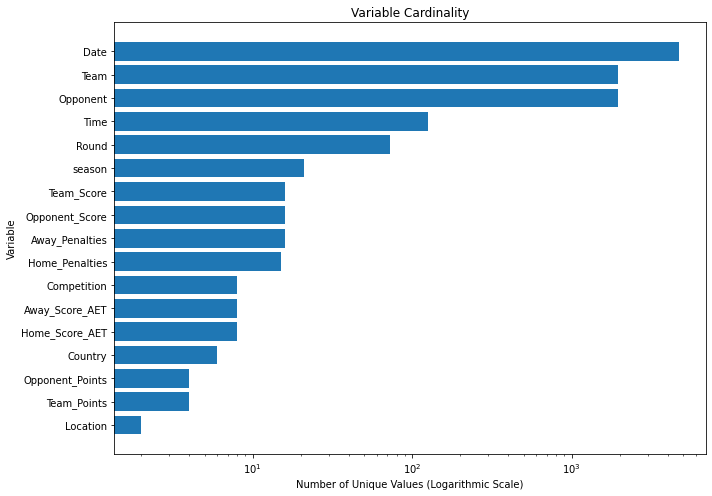

In [80]:
# Visualize the number of unique values for each variable
plt.figure(figsize=(10, 7))
plt.barh(
    cardinality_summary.index,
    cardinality_summary["Unique Values"],
)

# Use a logarithmic scale to make large differences easier to compare
plt.xscale("log")
plt.xlabel("Number of Unique Values (Logarithmic Scale)")
plt.ylabel("Variable")
plt.title("Variable Cardinality")
plt.tight_layout()
plt.show()

### Cardinality Discussion

Low-cardinality variables such as `Location`, `Country`, and `Competition` are suitable for group comparisons and frequency charts.

High-cardinality variables such as `Team`, `Opponent`, and `Date` remain useful, but visualizing every distinct value would be difficult to interpret. Filtering, aggregation, or selecting the most frequent values is more appropriate.

No variable should be removed solely because of high cardinality. The analytical meaning of the variable must be considered together with its number of distinct values.

# 5. Univariate Analysis

Univariate analysis examines each variable independently. Numerical and categorical variables require different statistical summaries and visual methods.

## 5.1 Numerical Variables

The main numerical football outcomes are analyzed using central tendency, variability, skewness, distribution plots, and three outlier-detection methods.

The `season` variable is excluded from this numerical summary because it represents a temporal category rather than a continuous measurement.

In [81]:
# Select the numerical variables for the univariate analysis
numerical_analysis_columns = [
    "Team_Score",
    "Opponent_Score",
    "Home_Score_AET",
    "Away_Score_AET",
    "Home_Penalties",
    "Away_Penalties",
    "Team_Points",
    "Opponent_Points",
]

# Calculate descriptive statistics for each numerical variable
def calculate_numerical_summary(
    dataframe: pd.DataFrame,
    columns: list[str],
) -> pd.DataFrame:
    summary_records = []

    for column_name in columns:
        valid_values = dataframe[column_name].dropna()

        first_quartile = valid_values.quantile(0.25)
        third_quartile = valid_values.quantile(0.75)
        median_value = valid_values.median()
        mad_value = np.median(
            np.abs(valid_values - median_value)
        )

        summary_records.append({
            "Variable": column_name,
            "Valid Count": valid_values.count(),
            "Mean": valid_values.mean(),
            "Median": median_value,
            "Standard Deviation": valid_values.std(),
            "MAD": mad_value,
            "Minimum": valid_values.min(),
            "Q1": first_quartile,
            "Q3": third_quartile,
            "Maximum": valid_values.max(),
            "IQR": third_quartile - first_quartile,
            "Skewness": valid_values.skew(),
        })

    return (
        pd.DataFrame(summary_records)
        .set_index("Variable")
        .round(3)
    )

# Generate and display the numerical summary table
numerical_summary = calculate_numerical_summary(
    football_matches_df,
    numerical_analysis_columns,
)

numerical_summary

,Valid Count,Mean,Median,Standard Deviation,MAD,Minimum,Q1,Q3,Maximum,IQR,Skewness
Variable,,,,,,,,,,,
Team_Score,104412,1.351,1.0,1.259,1.0,0.0,0.0,2.0,15.0,2.0,1.158
Opponent_Score,104412,1.351,1.0,1.259,1.0,0.0,0.0,2.0,15.0,2.0,1.158
Home_Score_AET,3024,1.462,1.0,1.149,1.0,0.0,1.0,2.0,8.0,1.0,0.705
Away_Score_AET,3024,1.434,1.0,1.125,1.0,0.0,1.0,2.0,6.0,1.0,0.766
Home_Penalties,1806,3.853,4.0,1.806,1.0,0.0,3.0,5.0,13.0,2.0,0.992
Away_Penalties,1806,3.951,4.0,1.770,1.0,0.0,3.0,5.0,14.0,2.0,0.974
Team_Points,104412,1.387,1.0,1.337,1.0,0.0,0.0,3.0,3.0,3.0,0.242
Opponent_Points,104412,1.387,1.0,1.337,1.0,0.0,0.0,3.0,3.0,3.0,0.242


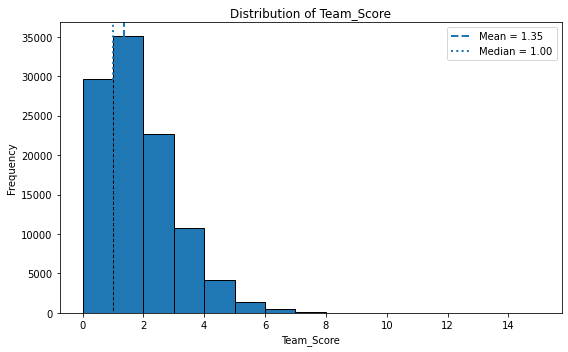

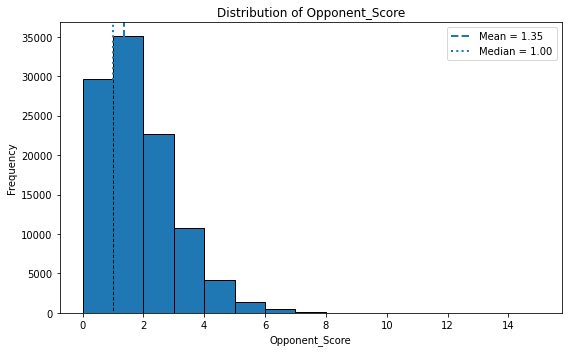

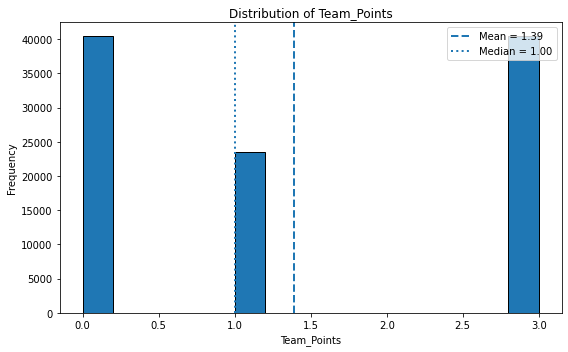

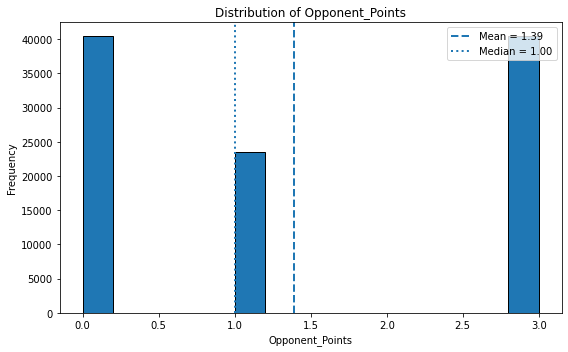

In [82]:
# Plot the distribution of a numerical variable with mean and median markers
def plot_histogram_with_center(
    dataframe: pd.DataFrame,
    column_name: str,
    bins: int = 15,
) -> None:
    valid_values = dataframe[column_name].dropna()

    plt.figure(figsize=(8, 5))
    plt.hist(valid_values, bins=bins, edgecolor="black")

    plt.axvline(
        valid_values.mean(),
        linestyle="--",
        linewidth=2,
        label=f"Mean = {valid_values.mean():.2f}",
    )

    plt.axvline(
        valid_values.median(),
        linestyle=":",
        linewidth=2,
        label=f"Median = {valid_values.median():.2f}",
    )

    plt.xlabel(column_name)
    plt.ylabel("Frequency")
    plt.title(f"Distribution of {column_name}")
    plt.legend()
    plt.tight_layout()
    plt.show()

# Plot the distributions of the main score and point variables
for column_name in [
    "Team_Score",
    "Opponent_Score",
    "Team_Points",
    "Opponent_Points",
]:
    plot_histogram_with_center(
        football_matches_df,
        column_name,
    )

In [83]:
# Detect outliers using the IQR rule
def detect_iqr_outliers(
    series: pd.Series,
    multiplier: float = 1.5,
) -> pd.Series:
    valid_values = series.dropna()
    q1 = valid_values.quantile(0.25)
    q3 = valid_values.quantile(0.75)
    iqr = q3 - q1

    lower_limit = q1 - multiplier * iqr
    upper_limit = q3 + multiplier * iqr

    return valid_values[
        (valid_values < lower_limit)
        | (valid_values > upper_limit)
    ]


# Detect outliers using the standard Z-score
def detect_z_score_outliers(
    series: pd.Series,
    threshold: float = 3.0,
) -> pd.Series:
    valid_values = series.dropna()
    standard_deviation = valid_values.std()

    if standard_deviation == 0:
        return valid_values.iloc[0:0]

    z_scores = (
        valid_values - valid_values.mean()
    ) / standard_deviation

    return valid_values[z_scores.abs() > threshold]


# Detect outliers using the modified Z-score based on median and MAD
def detect_modified_z_score_outliers(
    series: pd.Series,
    threshold: float = 3.5,
) -> pd.Series:
    valid_values = series.dropna()
    median_value = valid_values.median()

    mad_value = np.median(
        np.abs(valid_values - median_value)
    )

    if mad_value == 0:
        return valid_values.iloc[0:0]

    modified_z_scores = (
        0.6745
        * (valid_values - median_value)
        / mad_value
    )

    return valid_values[
        np.abs(modified_z_scores) > threshold
    ]

In [84]:
outlier_summary_records = []

# Apply all three outlier-detection methods to each numerical variable
for column_name in numerical_analysis_columns:
    valid_count = football_matches_df[column_name].count()

    iqr_outliers = detect_iqr_outliers(
        football_matches_df[column_name]
    )

    z_outliers = detect_z_score_outliers(
        football_matches_df[column_name]
    )

    modified_z_outliers = detect_modified_z_score_outliers(
        football_matches_df[column_name]
    )

    outlier_summary_records.append({
        "Variable": column_name,
        "Valid Count": valid_count,
        "IQR Outliers": len(iqr_outliers),
        "IQR Percentage": len(iqr_outliers) / valid_count * 100,
        "Z-Score Outliers": len(z_outliers),
        "Z-Score Percentage": len(z_outliers) / valid_count * 100,
        "Modified Z Outliers": len(modified_z_outliers),
        "Modified Z Percentage": (
            len(modified_z_outliers) / valid_count * 100
        ),
    })

# Create and display the outlier comparison table
outlier_summary = (
    pd.DataFrame(outlier_summary_records)
    .set_index("Variable")
    .round(3)
)

outlier_summary

,Valid Count,IQR Outliers,IQR Percentage,Z-Score Outliers,Z-Score Percentage,Modified Z Outliers,Modified Z Percentage
Variable,,,,,,,
Team_Score,104412,720,0.690,720,0.690,224,0.215
Opponent_Score,104412,720,0.690,720,0.690,224,0.215
Home_Score_AET,3024,158,5.225,26,0.860,2,0.066
Away_Score_AET,3024,126,4.167,38,1.257,0,0.000
Home_Penalties,1806,36,1.993,20,1.107,20,1.107
Away_Penalties,1806,30,1.661,16,0.886,16,0.886
Team_Points,104412,0,0.000,0,0.000,0,0.000
Opponent_Points,104412,0,0.000,0,0.000,0,0.000


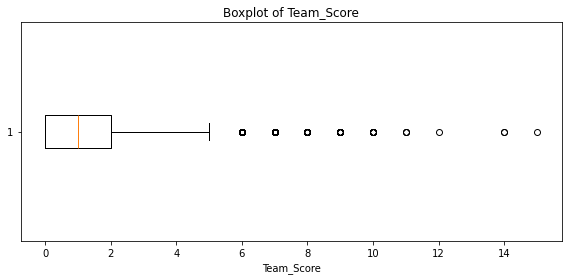

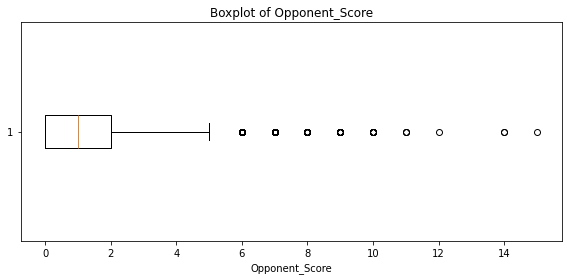

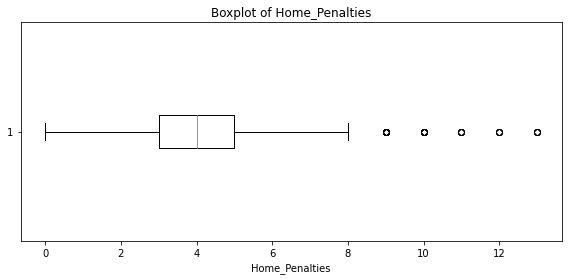

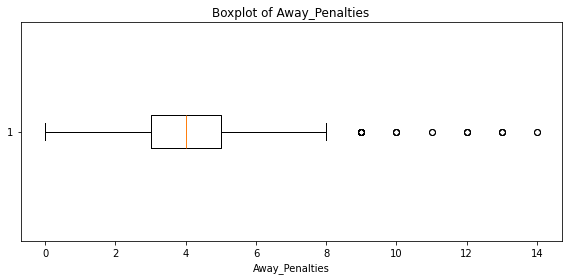

In [85]:
# Plot boxplots for selected numerical variables
for column_name in [
    "Team_Score",
    "Opponent_Score",
    "Home_Penalties",
    "Away_Penalties",
]:
    valid_values = football_matches_df[column_name].dropna()

    plt.figure(figsize=(8, 4))
    plt.boxplot(valid_values, vert=False)
    plt.xlabel(column_name)
    plt.title(f"Boxplot of {column_name}")
    plt.tight_layout()
    plt.show()

### Numerical-Variable Discussion

Football scores are discrete and are generally expected to be positively skewed. Most matches contain few goals, while very high scores are rare. Consequently, the median and IQR may describe a typical match better than the mean and standard deviation.

The IQR rule is robust but can label valid high-scoring matches as outliers. The standard Z-score is sensitive to skewness and assumes that the mean and standard deviation adequately describe the distribution. The modified Z-score is more robust because it uses the median and MAD, although it cannot distinguish observations when the MAD is zero.

Statistical outliers are retained because rarity does not imply an error. Their context should be examined before any removal decision.

## 5.2 Categorical Variables

Categorical variables are analyzed using frequencies, dominant-category percentages, top-\(K\) coverage, minimum category coverage for a selected percentage \(P\), and rare-category detection.

In [86]:
# Select the categorical variables for analysis
categorical_columns = [
    "Round",
    "Team",
    "Opponent",
    "Location",
    "Country",
    "Competition",
]

categorical_summary_records = []

# Calculate frequency information for each categorical variable
for column_name in categorical_columns:
    value_counts = football_matches_df[
        column_name
    ].value_counts(dropna=False)

    most_common_value = value_counts.index[0]
    most_common_count = value_counts.iloc[0]

    categorical_summary_records.append({
        "Variable": column_name,
        "Unique Values": value_counts.size,
        "Most Common Value": most_common_value,
        "Most Common Count": most_common_count,
        "Most Common Percentage": (
            most_common_count
            / len(football_matches_df)
            * 100
        ),
    })

# Create and display the categorical summary table
categorical_summary = (
    pd.DataFrame(categorical_summary_records)
    .set_index("Variable")
    .round(3)
)

categorical_summary

,Unique Values,Most Common Value,Most Common Count,Most Common Percentage
Variable,,,,
Round,73,group-stage,6912,6.467
Team,1966,BARCELONA,1141,1.068
Opponent,1966,BARCELONA,1141,1.068
Location,2,Home,53438,50.000
Country,6,england,22220,20.790
Competition,8,fa-cup,20172,18.874


In [87]:
TOP_K = 10
TARGET_COVERAGE = 0.80

# Calculate category coverage statistics for a categorical variable
def categorical_coverage_summary(
    series: pd.Series,
    top_k: int = TOP_K,
    target_coverage: float = TARGET_COVERAGE,
) -> dict:
    value_counts = series.value_counts(
        dropna=False
    )

    proportions = value_counts / value_counts.sum()
    cumulative_proportions = proportions.cumsum()

    # Find the minimum number of categories needed to reach the target coverage
    minimum_category_count = int(
        (cumulative_proportions < target_coverage).sum() + 1
    )

    return {
        "Unique Categories": value_counts.size,
        f"Top {top_k} Coverage (%)": (
            proportions.head(top_k).sum() * 100
        ),
        f"Categories for {target_coverage:.0%} Coverage": (
            minimum_category_count
        ),
        "Coverage Categories": list(
            value_counts.index[:minimum_category_count]
        ),
    }

# Apply the coverage analysis to all categorical variables
coverage_records = []

for column_name in categorical_columns:
    coverage_result = categorical_coverage_summary(
        football_matches_df[column_name]
    )

    coverage_result["Variable"] = column_name
    coverage_records.append(coverage_result)

# Create and display the coverage summary table
categorical_coverage_table = (
    pd.DataFrame(coverage_records)
    .set_index("Variable")
)

categorical_coverage_table

,Unique Categories,Top 10 Coverage (%),Categories for 80% Coverage,Coverage Categories
Variable,,,,
Round,73,27.312025,38,"[group-stage, first-round, second-round, third..."
Team,1966,10.046222,147,"[BARCELONA, REAL MADRID, CHELSEA, MANCHESTER U..."
Opponent,1966,10.046222,147,"[BARCELONA, REAL MADRID, CHELSEA, MANCHESTER U..."
Location,2,100.000000,2,"[Home, Away]"
Country,6,100.000000,5,"[england, france, spain, italy, germany]"
Competition,8,100.000000,6,"[fa-cup, ligue-1, premier-league, primera-divi..."


In [88]:
# Create frequency tables for selected categorical variables
for column_name in [
    "Location",
    "Country",
    "Competition",
]:
    value_counts = (
        football_matches_df[column_name]
        .value_counts(dropna=False)
    )

    percentages = (
        value_counts / value_counts.sum() * 100
    )

    # Combine count, percentage, and cumulative percentage
    frequency_table = pd.DataFrame({
        "Count": value_counts,
        "Percentage": percentages.round(2),
        "Cumulative Percentage": (
            percentages.cumsum().round(2)
        ),
    })

    print(f"\nFrequency table for {column_name}:")
    display(frequency_table)


Frequency table for Location:


,Count,Percentage,Cumulative Percentage
Location,,,
Home,53438,50.0,50.0
Away,53438,50.0,100.0



Frequency table for Country:


,Count,Percentage,Cumulative Percentage
Country,,,
england,22220,20.79,20.79
france,20946,19.60,40.39
spain,19744,18.47,58.86
italy,18210,17.04,75.90
germany,15450,14.46,90.36
europe-uefa,10306,9.64,100.00



Frequency table for Competition:


,Count,Percentage,Cumulative Percentage
Competition,,,
fa-cup,20172,18.87,18.87
ligue-1,15962,14.94,33.81
premier-league,15960,14.93,48.74
primera-division,15960,14.93,63.68
serie-a,15664,14.66,78.33
bundesliga,12852,12.03,90.36
uefa-europa-league,5222,4.89,95.24
uefa-champions-league,5084,4.76,100.00


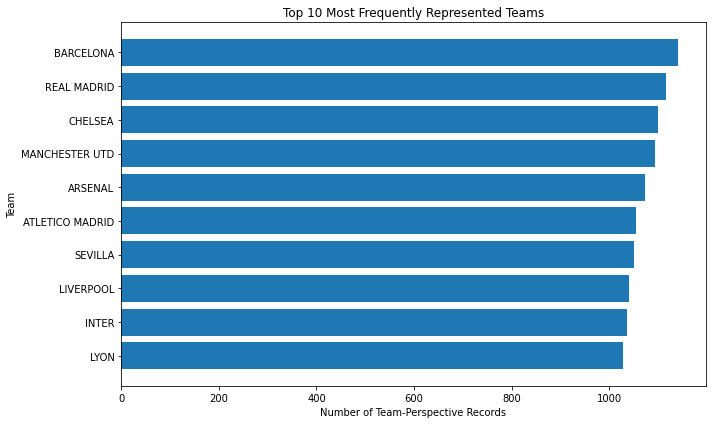

In [89]:
# Select the 10 most frequently represented teams
top_teams = (
    football_matches_df["Team"]
    .value_counts()
    .head(TOP_K)
    .sort_values()
)

# Plot the most frequently represented teams
plt.figure(figsize=(10, 6))
plt.barh(top_teams.index, top_teams.values)
plt.xlabel("Number of Team-Perspective Records")
plt.ylabel("Team")
plt.title(f"Top {TOP_K} Most Frequently Represented Teams")
plt.tight_layout()
plt.show()

In [90]:
# Define a category as rare if it represents less than 0.1% of the data
RARE_CATEGORY_THRESHOLD = 0.001

rare_category_summary = []

# Identify rare categories in each categorical variable
for column_name in categorical_columns:
    proportions = (
        football_matches_df[column_name]
        .value_counts(dropna=False, normalize=True)
    )

    rare_categories = proportions[
        proportions < RARE_CATEGORY_THRESHOLD
    ]

    rare_category_summary.append({
        "Variable": column_name,
        "Rare Category Count": len(rare_categories),
        "Rows in Rare Categories": int(
            football_matches_df[column_name]
            .isin(rare_categories.index)
            .sum()
        ),
        "Rare Category Threshold": (
            RARE_CATEGORY_THRESHOLD
        ),
    })

# Display the rare-category summary
pd.DataFrame(rare_category_summary).set_index(
    "Variable"
)

,Rare Category Count,Rows in Rare Categories,Rare Category Threshold
Variable,,,
Round,13,724,0.001
Team,1782,16411,0.001
Opponent,1782,16411,0.001
Location,0,0,0.001
Country,0,0,0.001
Competition,0,0,0.001


### Categorical-Variable Discussion

The most frequent category and its percentage reveal whether a variable is dominated by a small number of values. Top-\(K\) coverage shows how much of the dataset can be described using the most common categories.

The minimum number of categories required to cover 80% of the data is especially informative for high-cardinality variables such as teams and rounds. A large required number indicates a diverse distribution.

Rare teams or rounds should not automatically be removed. They may represent promoted clubs, lower-frequency competitions, special tournament stages, or historically important events. Categories may be grouped into `Other` for a specific visualization, but the original values should remain available for detailed analysis.

### Chapter 5 Conclusion

The numerical variables are discrete and often skewed, making robust statistics important. The categorical variables contain both compact variables, such as location and competition, and high-cardinality variables, such as team and opponent.

No single central measure fully represents the dataset. Numerical summaries should be combined with distribution plots, while categorical summaries should consider both dominant and rare categories.

# 6. Correlations and Relationships

This chapter examines numerical-numerical, categorical-categorical, and categorical-numerical relationships. Because each physical match can appear twice, the results describe team-perspective records unless stated otherwise.

## 6.1 Numerical–Numerical Relationships

Pearson, Spearman, and Kendall correlations measure different forms of association:

- **Pearson correlation** measures linear association and is sensitive to extreme values.
- **Spearman correlation** measures monotonic association using ranks and is less sensitive to outliers.
- **Kendall correlation** also uses ranks and measures concordance between observation pairs. It is often more conservative and computationally slower.

In [91]:
# Select numerical variables for correlation analysis
correlation_columns = [
    "Team_Score",
    "Opponent_Score",
    "Team_Points",
    "Opponent_Points",
    "Home_Score_AET",
    "Away_Score_AET",
    "Home_Penalties",
    "Away_Penalties",
]

# Calculate Pearson, Spearman, and Kendall correlation matrices
pearson_correlation = football_matches_df[
    correlation_columns
].corr(method="pearson")

spearman_correlation = football_matches_df[
    correlation_columns
].corr(method="spearman")

kendall_correlation = football_matches_df[
    correlation_columns
].corr(method="kendall")

# Display the correlation matrices
display(pearson_correlation.round(3))
display(spearman_correlation.round(3))
display(kendall_correlation.round(3))

,Team_Score,Opponent_Score,Team_Points,Opponent_Points,Home_Score_AET,Away_Score_AET,Home_Penalties,Away_Penalties
Team_Score,1.000,-0.097,0.638,-0.589,0.737,0.708,-0.003,-0.013
Opponent_Score,-0.097,1.000,-0.589,0.638,0.737,0.708,-0.003,-0.013
Team_Points,0.638,-0.589,1.000,-0.951,-0.001,-0.001,0.000,-0.000
Opponent_Points,-0.589,0.638,-0.951,1.000,-0.001,-0.001,-0.000,0.000
Home_Score_AET,0.737,0.737,-0.001,-0.001,1.000,0.512,0.009,0.027
Away_Score_AET,0.708,0.708,-0.001,-0.001,0.512,1.000,0.013,0.033
Home_Penalties,-0.003,-0.003,0.000,-0.000,0.009,0.013,1.000,0.617
Away_Penalties,-0.013,-0.013,-0.000,0.000,0.027,0.033,0.617,1.000


,Team_Score,Opponent_Score,Team_Points,Opponent_Points,Home_Score_AET,Away_Score_AET,Home_Penalties,Away_Penalties
Team_Score,1.000,-0.079,0.655,-0.655,0.750,0.716,-0.011,-0.026
Opponent_Score,-0.079,1.000,-0.655,0.655,0.750,0.716,-0.011,-0.026
Team_Points,0.655,-0.655,1.000,-1.000,0.000,0.000,0.000,0.000
Opponent_Points,-0.655,0.655,-1.000,1.000,0.000,0.000,0.000,0.000
Home_Score_AET,0.750,0.750,0.000,0.000,1.000,0.534,-0.002,0.001
Away_Score_AET,0.716,0.716,0.000,0.000,0.534,1.000,-0.000,0.013
Home_Penalties,-0.011,-0.011,0.000,0.000,-0.002,-0.000,1.000,0.434
Away_Penalties,-0.026,-0.026,0.000,0.000,0.001,0.013,0.434,1.000


,Team_Score,Opponent_Score,Team_Points,Opponent_Points,Home_Score_AET,Away_Score_AET,Home_Penalties,Away_Penalties
Team_Score,1.000,-0.066,0.576,-0.576,0.691,0.660,-0.009,-0.022
Opponent_Score,-0.066,1.000,-0.576,0.576,0.691,0.660,-0.009,-0.022
Team_Points,0.576,-0.576,1.000,-1.000,0.000,0.000,0.000,0.000
Opponent_Points,-0.576,0.576,-1.000,1.000,0.000,0.000,0.000,0.000
Home_Score_AET,0.691,0.691,0.000,0.000,1.000,0.462,-0.002,0.001
Away_Score_AET,0.660,0.660,0.000,0.000,0.462,1.000,-0.001,0.010
Home_Penalties,-0.009,-0.009,0.000,0.000,-0.002,-0.001,1.000,0.362
Away_Penalties,-0.022,-0.022,0.000,0.000,0.001,0.010,0.362,1.000


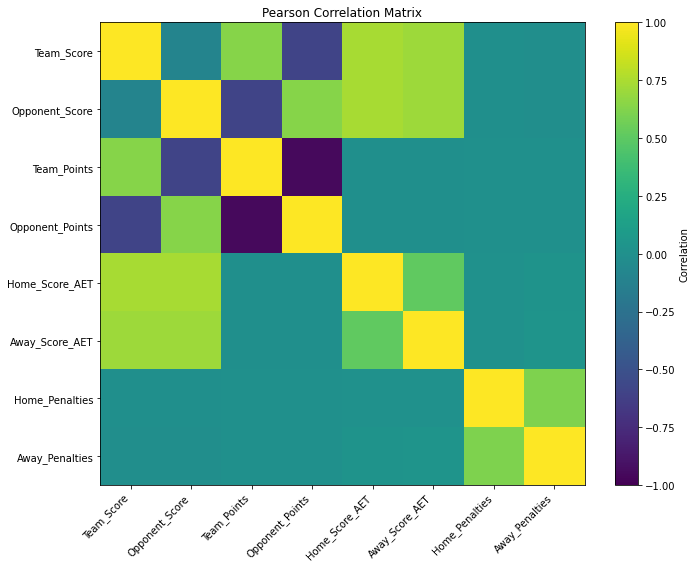

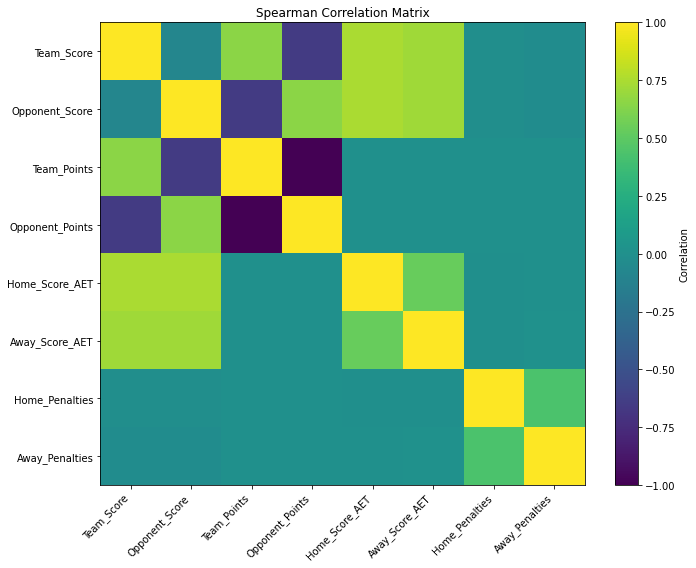

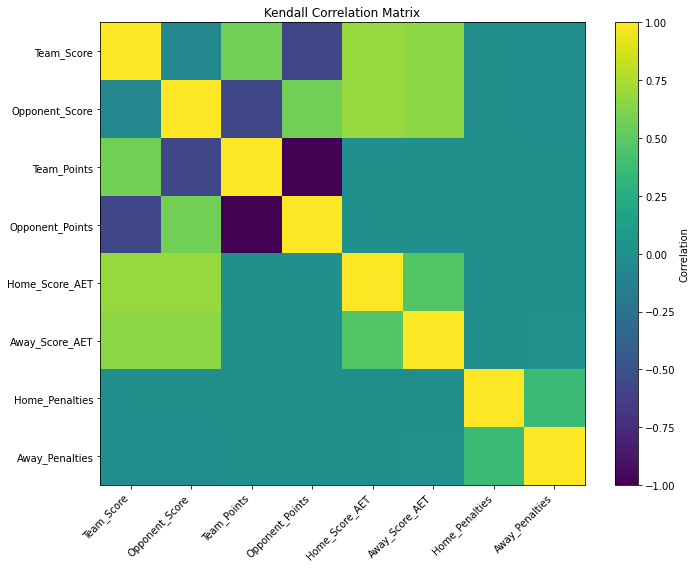

In [92]:
# Plot a heatmap for a correlation matrix
def plot_correlation_heatmap(
    correlation_matrix: pd.DataFrame,
    title: str,
) -> None:
    plt.figure(figsize=(10, 8))

    image = plt.imshow(
        correlation_matrix,
        vmin=-1,
        vmax=1,
        aspect="auto",
    )

    plt.colorbar(image, label="Correlation")

    plt.xticks(
        range(len(correlation_matrix.columns)),
        correlation_matrix.columns,
        rotation=45,
        ha="right",
    )

    plt.yticks(
        range(len(correlation_matrix.index)),
        correlation_matrix.index,
    )

    plt.title(title)
    plt.tight_layout()
    plt.show()

# Visualize the three correlation matrices
plot_correlation_heatmap(
    pearson_correlation,
    "Pearson Correlation Matrix",
)

plot_correlation_heatmap(
    spearman_correlation,
    "Spearman Correlation Matrix",
)

plot_correlation_heatmap(
    kendall_correlation,
    "Kendall Correlation Matrix",
)

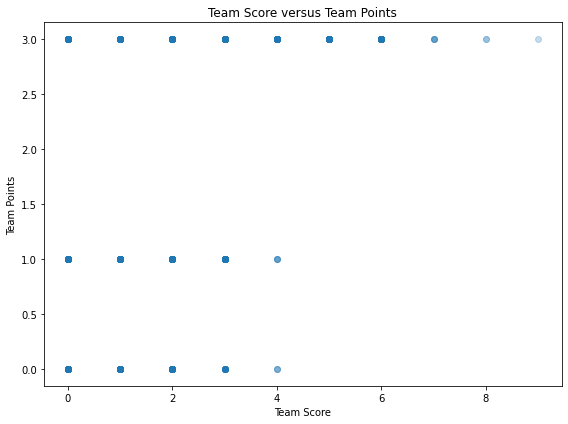

In [93]:
# Take a random sample to make the visualization clearer and faster
plot_sample = football_matches_df.sample(
    n=min(5000, len(football_matches_df)),
    random_state=42,
)

# Plot the relationship between team score and team points
plt.figure(figsize=(8, 6))
plt.scatter(
    plot_sample["Team_Score"],
    plot_sample["Team_Points"],
    alpha=0.25,
)

plt.xlabel("Team Score")
plt.ylabel("Team Points")
plt.title("Team Score versus Team Points")
plt.tight_layout()
plt.show()

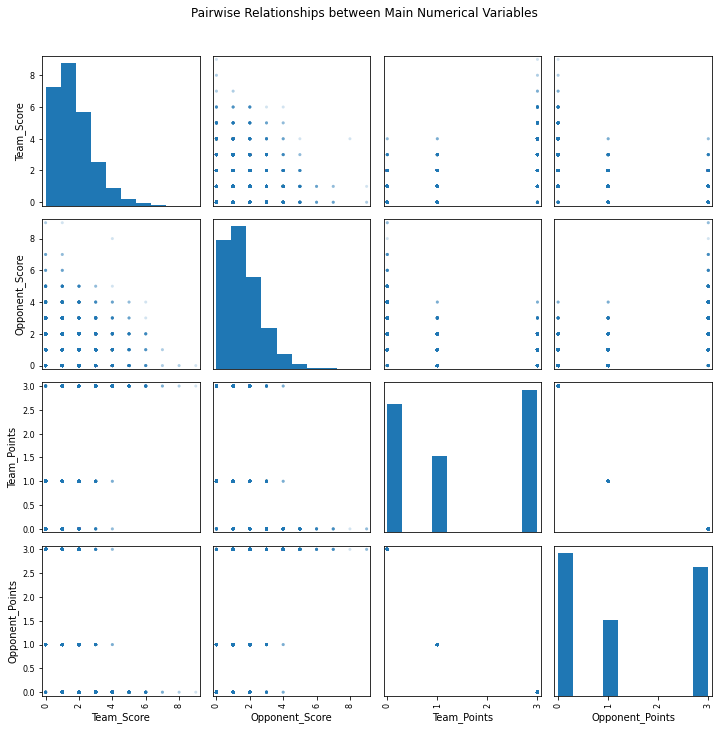

In [94]:
# Select the main numerical variables for pairwise comparison
scatter_matrix_columns = [
    "Team_Score",
    "Opponent_Score",
    "Team_Points",
    "Opponent_Points",
]

# Plot pairwise relationships between the selected variables
scatter_matrix(
    plot_sample[scatter_matrix_columns],
    figsize=(10, 10),
    diagonal="hist",
    alpha=0.2,
)

plt.suptitle(
    "Pairwise Relationships between Main Numerical Variables",
    y=1.02,
)

plt.tight_layout()
plt.show()

### Numerical-Relationship Discussion

Team points are expected to increase when the team score exceeds the opponent score. This creates a strong association between goals, goal difference, and points, but the relationship is not purely linear because points take only a few discrete values.

The score variables may show weaker Pearson correlation than rank-based measures if the relationship is monotonic but non-linear. Extra-time and penalty correlations are based only on the subset of matches with available values, so they should not be generalized to all matches.

Correlation does not establish causation. Some relationships are mechanically defined by football scoring rules rather than representing an independent predictive effect.

## 6.2 Categorical–Categorical Relationships

Contingency tables are used to compare category combinations. Cramér's \(V\) is added as an optional normalized measure of association.

In [95]:
# Compare the percentage of Home and Away records within each competition
location_competition_table = pd.crosstab(
    football_matches_df["Competition"],
    football_matches_df["Location"],
    normalize="index",
) * 100

# Display the contingency table as percentages
location_competition_table.round(2)

Location,Away,Home
Competition,,
bundesliga,50.0,50.0
fa-cup,50.0,50.0
ligue-1,50.0,50.0
premier-league,50.0,50.0
primera-division,50.0,50.0
serie-a,50.0,50.0
uefa-champions-league,50.0,50.0
uefa-europa-league,50.0,50.0


In [96]:
# Create a contingency table between country and competition
country_competition_table = pd.crosstab(
    football_matches_df["Country"],
    football_matches_df["Competition"],
)

# Display the number of records for each country-competition combination
country_competition_table

Competition,bundesliga,fa-cup,ligue-1,premier-league,primera-division,serie-a,uefa-champions-league,uefa-europa-league
Country,,,,,,,,
england,0,6260,0,15960,0,0,0,0
europe-uefa,0,0,0,0,0,0,5084,5222
france,0,4984,15962,0,0,0,0,0
germany,12852,2598,0,0,0,0,0,0
italy,0,2546,0,0,0,15664,0,0
spain,0,3784,0,0,15960,0,0,0


In [97]:
# Calculate Cramér's V to measure association between categorical variables
def cramers_v(
    first_series: pd.Series,
    second_series: pd.Series,
) -> float:
    contingency_table = pd.crosstab(
        first_series,
        second_series,
    )

    observed = contingency_table.to_numpy()
    total_count = observed.sum()

    row_totals = observed.sum(axis=1, keepdims=True)
    column_totals = observed.sum(axis=0, keepdims=True)
    expected = row_totals @ column_totals / total_count

    valid_expected = expected > 0
    chi_square = (
        ((observed - expected) ** 2 / expected)[
            valid_expected
        ]
    ).sum()

    row_count, column_count = observed.shape
    denominator = total_count * min(
        row_count - 1,
        column_count - 1,
    )

    if denominator == 0:
        return np.nan

    return float(np.sqrt(chi_square / denominator))


# Compare selected pairs of categorical variables
categorical_pairs = [
    ("Country", "Competition"),
    ("Competition", "Location"),
    ("Round", "Competition"),
]

cramers_v_results = []

for first_column, second_column in categorical_pairs:
    cramers_v_results.append({
        "Variable 1": first_column,
        "Variable 2": second_column,
        "Cramer's V": cramers_v(
            football_matches_df[first_column],
            football_matches_df[second_column],
        ),
    })

# Display the association strength for each pair
pd.DataFrame(cramers_v_results).round(3)

,Variable 1,Variable 2,Cramer's V
0,Country,Competition,0.917
1,Competition,Location,0.000
2,Round,Competition,0.508


### Categorical-Relationship Discussion

A strong association between country and competition is expected because domestic competitions are tied to specific countries. This is a structural relationship rather than a surprising empirical discovery.

Round labels may also depend strongly on competition because league competitions use numbered rounds, while knockout competitions use stage names such as quarter-final, semi-final, and final.

Cramér's \(V\) summarizes association strength but does not explain the direction or cause of the relationship. The contingency tables remain necessary for interpretation.

## 6.3 Categorical–Numerical Relationships with Binning

Goal difference is engineered as a numerical match-performance feature. It is then converted into categorical bins to compare match outcomes and other categorical variables.

In [98]:
# Calculate the goal difference for each team-perspective record
football_matches_df["Goal_Difference"] = (
    football_matches_df["Team_Score"]
    - football_matches_df["Opponent_Score"]
)

# Convert goal difference into Win, Draw, or Loss categories
football_matches_df["Match_Result"] = pd.cut(
    football_matches_df["Goal_Difference"],
    bins=[-np.inf, -0.5, 0.5, np.inf],
    labels=["Loss", "Draw", "Win"],
)

# Group team scores into scoring-level categories
football_matches_df["Scoring_Level"] = pd.cut(
    football_matches_df["Team_Score"],
    bins=[-0.5, 0.5, 2.5, np.inf],
    labels=["No Goals", "1–2 Goals", "3+ Goals"],
)

# Display the newly created variables
football_matches_df[
    [
        "Team_Score",
        "Opponent_Score",
        "Goal_Difference",
        "Match_Result",
        "Scoring_Level",
    ]
].head()

,Team_Score,Opponent_Score,Goal_Difference,Match_Result,Scoring_Level
0,0.0,1.0,-1.0,Loss,No Goals
1,2.0,2.0,0.0,Draw,1–2 Goals
2,4.0,2.0,2.0,Win,3+ Goals
3,0.0,2.0,-2.0,Loss,No Goals
4,2.0,2.0,0.0,Draw,1–2 Goals


In [99]:
# Compare Win, Draw, and Loss percentages by match location
result_location_table = pd.crosstab(
    football_matches_df["Location"],
    football_matches_df["Match_Result"],
    normalize="index",
) * 100

# Display the result distribution as percentages
result_location_table.round(2)

Match_Result,Loss,Draw,Win
Location,,,
Away,44.46,25.69,29.85
Home,29.85,25.69,44.46


In [100]:
# Calculate average performance measures for Home and Away records
average_points_by_location = (
    football_matches_df
    .groupby("Location", observed=False)[
        ["Team_Points", "Goal_Difference", "Team_Score"]
    ]
    .mean()
    .round(3)
)

# Display the average values by match location
average_points_by_location

,Team_Points,Goal_Difference,Team_Score
Location,,,
Away,1.170,-0.307,1.198
Home,1.604,0.307,1.505


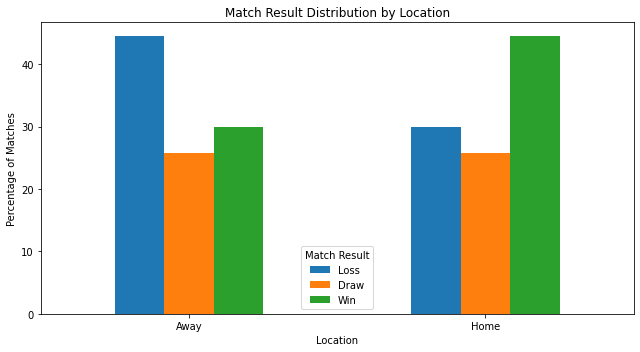

In [101]:
# Calculate match-result percentages for each location
result_percentages_by_location = (
    football_matches_df
    .groupby("Location", observed=False)[
        "Match_Result"
    ]
    .value_counts(normalize=True)
    .mul(100)
    .rename("Percentage")
    .reset_index()
)

# Reshape the data for visualization
pivot_result_percentages = (
    result_percentages_by_location
    .pivot(
        index="Location",
        columns="Match_Result",
        values="Percentage",
    )
)

# Plot the match-result distribution by location
pivot_result_percentages.plot(
    kind="bar",
    figsize=(9, 5),
)

plt.xlabel("Location")
plt.ylabel("Percentage of Matches")
plt.title("Match Result Distribution by Location")
plt.legend(title="Match Result")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Categorical–Numerical Discussion

Binning converts numerical outcomes into interpretable football categories. The match-result bins directly reflect whether the team scored fewer, equal, or more goals than its opponent.

Comparing these categories by location can reveal a home-advantage pattern. However, because each physical match appears from two perspectives, home and away observations are paired rather than statistically independent.

The engineered goal-difference variable is more informative than team score alone because it includes both attacking output and the opponent's score.

## 6.4 Visual Exploration

The following figures provide complementary views of distributions, category frequencies, group differences, and multivariable relationships.

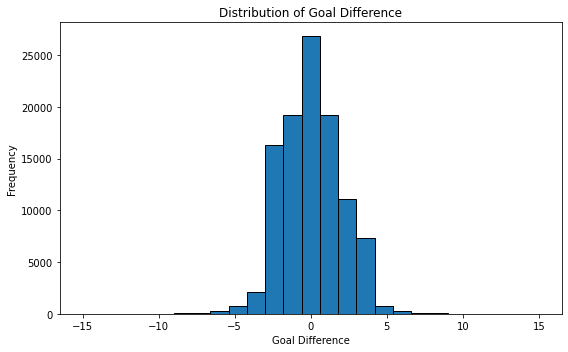

In [102]:
# Plot the distribution of goal difference
plt.figure(figsize=(8, 5))
plt.hist(
    football_matches_df["Goal_Difference"].dropna(),
    bins=25,
    edgecolor="black",
)

plt.xlabel("Goal Difference")
plt.ylabel("Frequency")
plt.title("Distribution of Goal Difference")
plt.tight_layout()
plt.show()

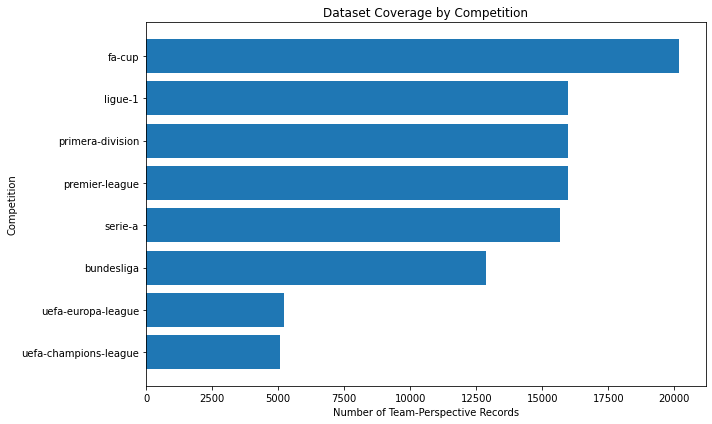

In [103]:
# Count the number of records for each competition
competition_counts = (
    football_matches_df["Competition"]
    .value_counts()
    .sort_values()
)

# Plot dataset coverage by competition
plt.figure(figsize=(10, 6))
plt.barh(
    competition_counts.index,
    competition_counts.values,
)

plt.xlabel("Number of Team-Perspective Records")
plt.ylabel("Competition")
plt.title("Dataset Coverage by Competition")
plt.tight_layout()
plt.show()

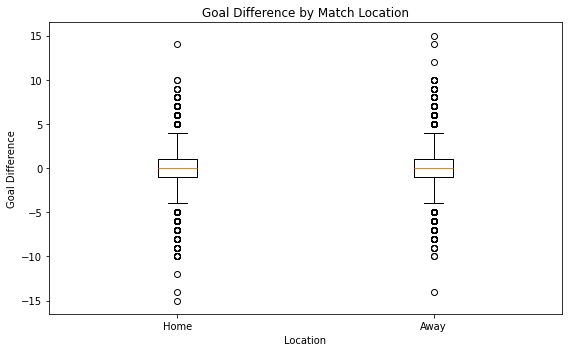

In [104]:
# Get the available match-location categories
location_order = football_matches_df[
    "Location"
].dropna().unique()

# Prepare goal-difference values for each location
boxplot_data = [
    football_matches_df.loc[
        football_matches_df["Location"] == location,
        "Goal_Difference",
    ].dropna()
    for location in location_order
]

# Compare goal-difference distributions between locations
plt.figure(figsize=(8, 5))
plt.boxplot(
    boxplot_data,
    tick_labels=location_order,
)

plt.xlabel("Location")
plt.ylabel("Goal Difference")
plt.title("Goal Difference by Match Location")
plt.tight_layout()
plt.show()

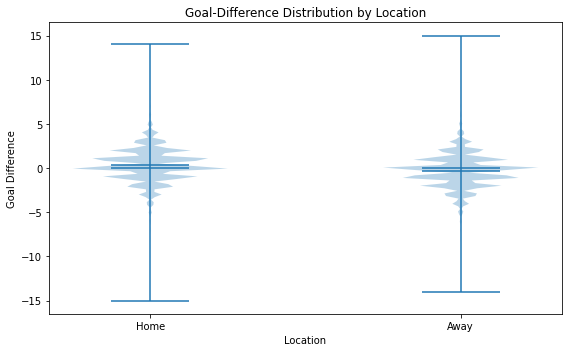

In [105]:
# Prepare goal-difference values for each match location
violin_data = [
    football_matches_df.loc[
        football_matches_df["Location"] == location,
        "Goal_Difference",
    ].dropna()
    for location in location_order
]

# Compare the shape and central tendency of the distributions
plt.figure(figsize=(8, 5))
plt.violinplot(
    violin_data,
    showmeans=True,
    showmedians=True,
)

plt.xticks(
    range(1, len(location_order) + 1),
    location_order,
)
plt.xlabel("Location")
plt.ylabel("Goal Difference")
plt.title("Goal-Difference Distribution by Location")
plt.tight_layout()
plt.show()

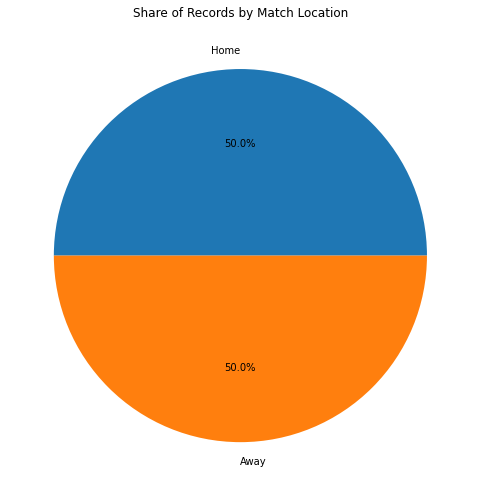

In [106]:
# Count the number of records for each match location
location_counts = (
    football_matches_df["Location"]
    .value_counts()
)

# Visualize the share of Home and Away records
plt.figure(figsize=(7, 7))
plt.pie(
    location_counts.values,
    labels=location_counts.index,
    autopct="%1.1f%%",
)

plt.title("Share of Records by Match Location")
plt.tight_layout()
plt.show()

### Visualization Insights

The histogram reveals whether goal difference is centered around zero and how quickly the distribution decreases toward extreme victories and defeats.

The competition bar chart shows whether the dataset is balanced across competitions. Large differences indicate that some competitions have greater influence on aggregate statistics.

The boxplot and violin plot compare the central tendency, spread, and shape of home and away goal differences. A shift toward positive values for home observations would support the presence of home advantage.

The pie chart verifies the balance between home and away perspectives. Near-equal shares are expected because most physical matches contribute one row for each side.

# 7. Index Analysis

The default DataFrame index is examined for uniqueness, ordering, and temporal meaning. A separate time-based view is created for chronological analysis.

In [107]:
# Examine the properties of the current DataFrame index
index_analysis = pd.Series({
    "Index is unique": football_matches_df.index.is_unique,
    "Index is monotonic increasing": (
        football_matches_df.index.is_monotonic_increasing
    ),
    "Index contains duplicates": (
        football_matches_df.index.duplicated().any()
    ),
    "Index data type": str(
        football_matches_df.index.dtype
    ),
})

# Display the index analysis
index_analysis

Index is unique                   True
Index is monotonic increasing     True
Index contains duplicates        False
Index data type                  int64
dtype: object

In [108]:
# Convert the Date column to datetime format
football_matches_df["Parsed_Date"] = pd.to_datetime(
    football_matches_df["Date"],
    errors="coerce",
    dayfirst=True,
)

# Check whether any dates could not be parsed
print(
    f"Unparsed dates: "
    f"{football_matches_df['Parsed_Date'].isna().sum():,}"
)

# Display the available date range
print(
    f"Date range: "
    f"{football_matches_df['Parsed_Date'].min()} "
    f"to "
    f"{football_matches_df['Parsed_Date'].max()}"
)

# Check whether the dates are already sorted
print(
    "Dates are sorted:",
    football_matches_df["Parsed_Date"]
    .is_monotonic_increasing,
)

Unparsed dates: 0
Date range: 2002-08-02 00:00:00 to 2023-06-04 00:00:00
Dates are sorted: False


In [109]:
# Sort the dataset chronologically
time_sorted_df = (
    football_matches_df
    .sort_values("Parsed_Date")
    .copy()
)

# Extract the year from each match date
time_sorted_df["Year"] = (
    time_sorted_df["Parsed_Date"].dt.year
)

# Calculate average performance measures for each year
annual_performance = (
    time_sorted_df
    .groupby("Year")[
        ["Team_Score", "Opponent_Score", "Goal_Difference"]
    ]
    .mean()
)

# Display the most recent 15 years
annual_performance.tail(15)

,Team_Score,Opponent_Score,Goal_Difference
Year,,,
2009,1.326690,1.326690,0.0
2010,1.334592,1.334592,0.0
2011,1.366450,1.366450,0.0
2012,1.379278,1.379278,0.0
2013,1.363164,1.363164,0.0
2014,1.338902,1.338902,0.0
2015,1.316323,1.316323,0.0
2016,1.389655,1.389655,0.0
2017,1.415838,1.415838,0.0


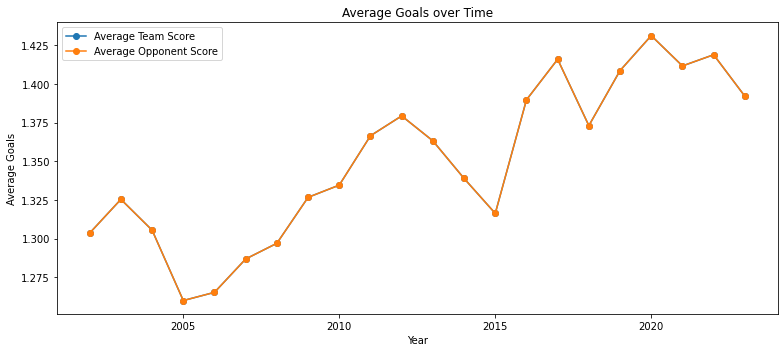

In [110]:
# Plot average team and opponent scores over time
plt.figure(figsize=(11, 5))

plt.plot(
    annual_performance.index,
    annual_performance["Team_Score"],
    marker="o",
    label="Average Team Score",
)

plt.plot(
    annual_performance.index,
    annual_performance["Opponent_Score"],
    marker="o",
    label="Average Opponent Score",
)

plt.xlabel("Year")
plt.ylabel("Average Goals")
plt.title("Average Goals over Time")
plt.legend()
plt.tight_layout()
plt.show()

### Index Discussion

The default integer index is unique and sorted, but it is not semantically meaningful and is not based on time. It identifies rows only according to their current order.

The date variable provides a more meaningful temporal index, but multiple matches occur on the same date, so date alone is not unique. A composite match identifier would be required for a unique match-level index.

Chronological sorting is necessary before time-series analysis. Changes over time may reflect real football developments, but they may also result from changes in competition coverage, rules, or the composition of teams included in the dataset.

# 8. Insights and the Data Story

The exploratory analysis shows that the dataset is rich and suitable for football analysis, but its internal structure strongly affects interpretation.

## 8.1 Main Insights

### Insight 1: The Dataset Is Perspective-Based

A physical match is generally represented twice, once from each team's perspective. This design is useful for team-level analysis, but it creates paired observations and can double-count matches in aggregate analyses. Match-level research should first construct a unique physical-match table.

### Insight 2: Missingness Is Often Structural

Missing values are concentrated in extra-time and penalty-shootout variables. In most cases, these values do not indicate failed data collection. They indicate that the event did not occur. Therefore, standard mean or median imputation would be conceptually incorrect.

### Insight 3: Football Outcomes Are Discrete and Skewed

Goals and points are not continuous normally distributed measurements. Most matches contain few goals, while high-scoring matches are rare. Robust measures such as the median and IQR complement the mean and standard deviation.

### Insight 4: Location Can Be Associated with Performance

Comparisons of goal difference, points, and match-result percentages between home and away records can reveal a home-advantage pattern. This relationship should be interpreted descriptively because the home and away rows from the same match are dependent.

### Insight 5: Dataset Composition Influences Every Aggregate Result

Countries, competitions, teams, and seasons are not necessarily represented equally. Overall averages may therefore reflect the dataset's composition as much as they reflect general European football behavior.

## 8.2 Biases and Risks

The main structural risk is pseudo-replication: the same physical match contributes two related rows. Statistical procedures that assume independent observations may produce overly confident results if this dependency is ignored.

Additional risks include incomplete source provenance, unequal competition coverage, changes in football rules over time, promoted and relegated teams, different tournament formats, and missing seasons or competitions.

The dataset should therefore not be treated as a complete or perfectly balanced representation of all European football.

## 8.3 Possible Failure Points in Engineering and Statistical Uses

- A predictive model may leak information if mirrored rows from the same match are split between training and test sets.
- A model may learn competition identity instead of a general football relationship if competitions are imbalanced.
- Missing extra-time values may be misinterpreted as numerical zeros or unknown measurements.
- Raw team names may contain spelling or naming changes across seasons.
- Correlation measures may be inflated by mechanically related variables, such as goal difference, result, and points.
- Time-based validation is required for forecasting because random train-test splitting can use future information to predict the past.
- Rare teams and competition stages may produce unstable estimates.

## 8.4 What Was Learned

The analysis changed the initial interpretation of the dataset from a simple table of independent matches to a perspective-based record system.

The most important lesson is that data values cannot be interpreted separately from the process that generated them. Missingness, duplication, and categorical imbalance are not merely cleaning problems; they describe the structure of football competitions and the organization of the source data.

The analysis also demonstrates that a statistically unusual observation is not necessarily incorrect. Domain knowledge is required to distinguish data errors from rare but valid football events.

# 9. Bonus Analysis

The bonus section includes temporal dependence, feature engineering, hypothesis tests, and proposals for further research.

## 9.1 Temporal Dependence

Annual and seasonal summaries are used to examine whether scoring patterns and home advantage change over time. Any trend must be interpreted together with changes in competition coverage and external football events.

In [111]:
# Summarize key football measures for each year
temporal_summary = (
    time_sorted_df
    .dropna(subset=["Year"])
    .groupby("Year")
    .agg(
        Average_Goals=("Team_Score", "mean"),
        Average_Goal_Difference=(
            "Goal_Difference",
            "mean",
        ),
        Average_Points=("Team_Points", "mean"),
        Number_of_Records=("Team", "size"),
    )
)

# Display the most recent 15 years
temporal_summary.tail(15)

,Average_Goals,Average_Goal_Difference,Average_Points,Number_of_Records
Year,,,,
2009,1.326690,0.0,1.389801,5118
2010,1.334592,0.0,1.381042,5296
2011,1.366450,0.0,1.384028,5234
2012,1.379278,0.0,1.391741,5376
2013,1.363164,0.0,1.385489,5196
2014,1.338902,0.0,1.391513,5210
2015,1.316323,0.0,1.390994,5332
2016,1.389655,0.0,1.387739,5220
2017,1.415838,0.0,1.397238,5430


In [112]:
# Calculate the average goal difference for Home and Away records by year
home_advantage_by_year = (
    time_sorted_df
    .dropna(subset=["Year", "Location"])
    .groupby(["Year", "Location"])[
        "Goal_Difference"
    ]
    .mean()
    .unstack()
)

# Display the most recent 15 years
home_advantage_by_year.tail(15)

Location,Away,Home
Year,,
2009,-0.325127,0.325127
2010,-0.441843,0.441843
2011,-0.395109,0.395109
2012,-0.367932,0.367932
2013,-0.334488,0.334488
2014,-0.332181,0.332181
2015,-0.321201,0.321201
2016,-0.360153,0.360153
2017,-0.338122,0.338122


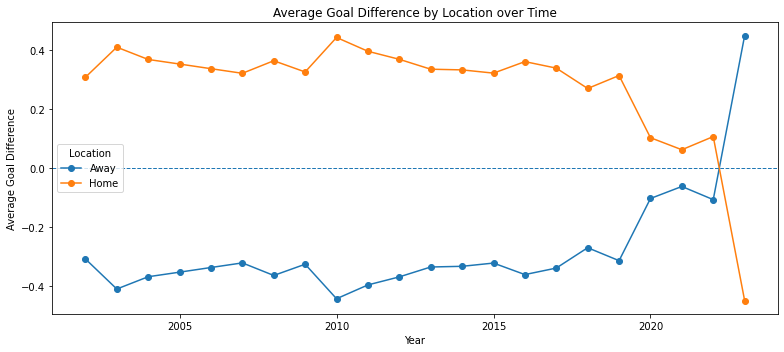

In [113]:
# Plot average goal difference for Home and Away records over time
plt.figure(figsize=(11, 5))

for location in home_advantage_by_year.columns:
    plt.plot(
        home_advantage_by_year.index,
        home_advantage_by_year[location],
        marker="o",
        label=location,
    )

# Add a zero reference line for easier interpretation
plt.axhline(0, linestyle="--", linewidth=1)

plt.xlabel("Year")
plt.ylabel("Average Goal Difference")
plt.title("Average Goal Difference by Location over Time")
plt.legend(title="Location")
plt.tight_layout()
plt.show()

### Temporal Interpretation

A time trend may reflect tactical developments, rule changes, competition expansion, changes in team composition, or exceptional external events.

A particularly relevant external event is the COVID-19 period, during which many matches were played with restricted or absent crowds. If the dataset covers this period, comparing home advantage before, during, and after the restrictions may provide a meaningful research question. However, the exact dates and competition-specific attendance policies would need to be verified using external sources.

## 9.2 Feature Engineering

New variables are created to represent match performance and context more directly.

In [114]:
# Create additional features for match analysis
football_matches_df["Total_Goals"] = (
    football_matches_df["Team_Score"]
    + football_matches_df["Opponent_Score"]
)

football_matches_df["Is_Home"] = (
    football_matches_df["Location"]
    .astype(str)
    .str.lower()
    .eq("home")
    .astype(int)
)

football_matches_df["Is_Draw"] = (
    football_matches_df["Team_Score"]
    == football_matches_df["Opponent_Score"]
).astype(int)

football_matches_df["High_Scoring_Match"] = (
    football_matches_df["Total_Goals"] >= 4
).astype(int)

# Display the engineered features
football_matches_df[
    [
        "Goal_Difference",
        "Total_Goals",
        "Match_Result",
        "Is_Home",
        "Is_Draw",
        "High_Scoring_Match",
    ]
].head()

,Goal_Difference,Total_Goals,Match_Result,Is_Home,Is_Draw,High_Scoring_Match
0,-1.0,1.0,Loss,1,0,0
1,0.0,4.0,Draw,1,1,1
2,2.0,6.0,Win,1,0,1
3,-2.0,2.0,Loss,1,0,0
4,0.0,4.0,Draw,1,1,1


### Feature-Engineering Discussion

`Goal_Difference` summarizes performance relative to the opponent. `Total_Goals` represents match openness or scoring intensity. `Is_Home` enables numerical modeling of location, while `Is_Draw` and `High_Scoring_Match` support classification and group comparison.

These features are derived from existing variables, so they should not be treated as independent evidence. For example, using goal difference to predict match result would create target leakage because match result is directly defined by goal difference.

## 9.3 Hypothesis Testing

Two non-parametric tests are implemented without requiring normally distributed football outcomes.

1. A permutation test compares average goal difference between home and away observations.
2. A bootstrap confidence interval estimates the difference in average goal difference.

In [115]:
# Extract goal differences for Home and Away records
home_goal_difference_full = (
    football_matches_df.loc[
        football_matches_df["Location"]
        .astype(str)
        .str.lower()
        .eq("home"),
        "Goal_Difference",
    ]
    .dropna()
    .to_numpy()
)

away_goal_difference_full = (
    football_matches_df.loc[
        football_matches_df["Location"]
        .astype(str)
        .str.lower()
        .eq("away"),
        "Goal_Difference",
    ]
    .dropna()
    .to_numpy()
)

# Use a reproducible random sample to reduce computation time
random_generator = np.random.default_rng(42)
maximum_test_sample_size = 5000

home_goal_difference = random_generator.choice(
    home_goal_difference_full,
    size=min(
        maximum_test_sample_size,
        len(home_goal_difference_full),
    ),
    replace=False,
)

away_goal_difference = random_generator.choice(
    away_goal_difference_full,
    size=min(
        maximum_test_sample_size,
        len(away_goal_difference_full),
    ),
    replace=False,
)

# Calculate the observed difference between Home and Away means
observed_mean_difference = (
    home_goal_difference.mean()
    - away_goal_difference.mean()
)

print(
    f"Observed home-minus-away mean goal difference: "
    f"{observed_mean_difference:.4f}"
)

print(
    f"Test sample sizes: "
    f"{len(home_goal_difference):,} home and "
    f"{len(away_goal_difference):,} away records"
)

Observed home-minus-away mean goal difference: 0.6334
Test sample sizes: 5,000 home and 5,000 away records


In [116]:
# Perform a permutation test for the difference between two means
def permutation_test_mean_difference(
    first_group: np.ndarray,
    second_group: np.ndarray,
    number_of_permutations: int = 2000,
    random_seed: int = 42,
) -> tuple[float, float]:
    random_generator = np.random.default_rng(
        random_seed
    )

    observed_difference = (
        first_group.mean()
        - second_group.mean()
    )

    combined_values = np.concatenate(
        [first_group, second_group]
    )
    first_group_size = len(first_group)

    permutation_differences = np.empty(
        number_of_permutations
    )

    # Randomly shuffle the group labels and recalculate the mean difference
    for permutation_index in range(
        number_of_permutations
    ):
        permuted_values = random_generator.permutation(
            combined_values
        )

        permutation_differences[
            permutation_index
        ] = (
            permuted_values[:first_group_size].mean()
            - permuted_values[first_group_size:].mean()
        )

    # Calculate a two-sided p-value
    p_value = (
        np.mean(
            np.abs(permutation_differences)
            >= abs(observed_difference)
        )
    )

    return observed_difference, p_value


# Run the test for Home versus Away goal difference
permutation_difference, permutation_p_value = (
    permutation_test_mean_difference(
        home_goal_difference,
        away_goal_difference,
    )
)

print(
    f"Permutation-test difference: "
    f"{permutation_difference:.4f}"
)

print(
    f"Two-sided permutation p-value: "
    f"{permutation_p_value:.4f}"
)

Permutation-test difference: 0.6334
Two-sided permutation p-value: 0.0000


In [117]:
# Estimate a confidence interval for the difference between two means
def bootstrap_mean_difference_interval(
    first_group: np.ndarray,
    second_group: np.ndarray,
    number_of_bootstrap_samples: int = 2000,
    confidence_level: float = 0.95,
    random_seed: int = 42,
) -> tuple[float, float]:
    random_generator = np.random.default_rng(
        random_seed
    )

    bootstrap_differences = np.empty(
        number_of_bootstrap_samples
    )

    # Resample both groups with replacement
    for bootstrap_index in range(
        number_of_bootstrap_samples
    ):
        first_sample = random_generator.choice(
            first_group,
            size=len(first_group),
            replace=True,
        )

        second_sample = random_generator.choice(
            second_group,
            size=len(second_group),
            replace=True,
        )

        bootstrap_differences[
            bootstrap_index
        ] = (
            first_sample.mean()
            - second_sample.mean()
        )

    # Calculate the confidence interval from the bootstrap distribution
    alpha = 1 - confidence_level

    return tuple(
        np.quantile(
            bootstrap_differences,
            [alpha / 2, 1 - alpha / 2],
        )
    )


# Calculate and display the 95% confidence interval
bootstrap_interval = (
    bootstrap_mean_difference_interval(
        home_goal_difference,
        away_goal_difference,
    )
)

print(
    f"95% bootstrap confidence interval: "
    f"[{bootstrap_interval[0]:.4f}, "
    f"{bootstrap_interval[1]:.4f}]"
)

95% bootstrap confidence interval: [0.5610, 0.7042]


### Hypothesis-Test Interpretation

The null hypothesis of the permutation test is that the home and away goal-difference observations are exchangeable and have no systematic difference in their means.

A small p-value provides evidence of an association between location and goal difference. The bootstrap interval estimates the plausible range of the mean difference.

The results should still be interpreted cautiously because the two perspective rows from each physical match are paired. A stronger confirmatory analysis would first construct one physical-match record and then use a paired method or a model that accounts for match-level dependence.

## 9.4 Suggestions for Further Research

- Construct a unique physical-match table and repeat the analysis without perspective duplication.
- Compare home advantage before, during, and after crowd restrictions.
- Investigate whether scoring rates differ by country, competition, and season.
- Examine promoted teams separately from established teams.
- Build time-aware predictive models using only information available before each match.
- Study team strength using rolling averages or Elo-style ratings.
- Analyze whether rare extreme scores are concentrated in specific competitions or historical periods.
- Verify team-name consistency and create a standardized team identifier.
- Compare regular-season matches with knockout matches.
- Add external information such as attendance, red cards, player injuries, weather, and betting odds.

# Final Conclusion

The European football dataset satisfies the assignment requirements and supports extensive exploratory analysis. Its greatest analytical strength is the combination of scores, points, teams, competitions, countries, locations, and time.

Its most important limitation is structural: one physical match is generally represented by two related team-perspective rows. This design must be considered in descriptive statistics, hypothesis tests, machine-learning validation, and any claim about independent observations.

Missing values are often meaningful, high-cardinality categories require careful visualization, and extreme scores require domain interpretation rather than automatic removal.

Overall, the analysis demonstrates that reliable data science begins with understanding how the data was generated. The dataset can support valuable football research, provided that duplication, temporal ordering, competition coverage, and variable definitions are handled explicitly.